# DeGroot model: how influence can shape opinions

People influence one another through social relationships. A network lets us ask theoretical questions such as:

- Can repeated interpersonal influence produce consensus?
- How does network structure affect the speed of convergence?
- Which assumptions are responsible for the observed outcome?

The value of the model is not that it reproduces society exactly. Its value is that it makes assumptions explicit and lets us examine their consequences.

## The DeGroot model

Each agent $i$ has a continuous opinion

$$
x_i(t) \in [0,1].
$$

At every round, all agents update synchronously:

$$
x_i(t+1)=\sum_{j=1}^{N} W_{ij}x_j(t),
$$
where $W_{ij}$ is the influence that agent $j$ has on agent $i$. The weights are nonnegative and every row sums to one:

$$
\sum_j W_{ij}=1.
$$

In this example, an agent gives equal weight to its own opinion and to the opinions of its network neighbors.

### Conventions used here

- **Opinion space:** continuous values in $[0,1]$.
- **Population:** 100 agents.
- **Topology:** one fixed, simple, connected, undirected Watts–Strogatz (WS) network.
- **Initial state:** each opinion is sampled independently from the uniform distribution on $[0,1]$ using `OPINION_SEED`.
- **Influence:** equal weight for the agent and each of its neighbors.
- **Update schedule:** synchronous; every update uses the unchanged opinions from the previous round.
- **Time:** one step means one complete update of all agents.
- **Observable:** the range between the largest and smallest opinions measures disagreement.
- **Consensus criterion:** opinion range strictly smaller than `CONSENSUS_TOLERANCE`.
- **Simulation horizon:** exactly `N_ROUNDS`; detecting consensus does not stop the simulation early.
- **Parameter ranges:** `N_ROUNDS >= 0`, `0 <= REWIRING_PROBABILITY <= 1`, `1 <= NEIGHBORS_ON_EACH_SIDE < N_AGENTS / 2`, and `CONSENSUS_TOLERANCE > 0`.

A row-stochastic influence matrix does not guarantee consensus for every possible network. Here, connectedness lets influence travel through the population, while positive self-weights prevent alternating oscillations. Together, these properties make this particular influence matrix primitive, which guarantees asymptotic consensus.

The limiting opinion is not generally the initial arithmetic mean because this influence matrix is not necessarily column-stochastic.

In [64]:
import random

import igraph as ig
import matplotlib.colors as mcolors
import matplotlib.pyplot as plt
import numpy as np

# Adjustable parameters
N_AGENTS = 100
N_ROUNDS = 50
NEIGHBORS_ON_EACH_SIDE = 3
REWIRING_PROBABILITY = 0.10
CONSENSUS_TOLERANCE = 0.01

# Visible fixed seeds make the example reproducible within this environment.
NETWORK_SEED = 2026
OPINION_SEED = 2027
LAYOUT_SEED = 2028

assert N_ROUNDS >= 0
assert 0 <= REWIRING_PROBABILITY <= 1
assert 1 <= NEIGHBORS_ON_EACH_SIDE < N_AGENTS / 2
assert CONSENSUS_TOLERANCE > 0

plt.rcParams.update({
    "figure.figsize": (9, 5),
    "font.size": 12,
    "axes.titlesize": 14,
    "axes.labelsize": 12,
})

## 1. Create the social network

We use `igraph` to create, store, lay out, and draw a small-world network. The parameter `NEIGHBORS_ON_EACH_SIDE = 3` starts each agent with three lattice neighbors on either side.

The `python-igraph` generator uses a small-world rewiring variant. This synthetic topology is a convenient theoretical influence structure, not a reconstruction of a real social network.

The force-directed layout affects only the drawing, not the influence matrix or dynamics. Fixed seeds make the generated network and layout reproducible within the specified software environment; results may differ across library versions.

In [65]:
# igraph uses this seeded generator for reproducible rewiring.
ig.set_random_number_generator(random.Random(NETWORK_SEED))

graph_ig = ig.Graph.Watts_Strogatz(
    dim=1,
    size=N_AGENTS,
    nei=NEIGHBORS_ON_EACH_SIDE,
    p=REWIRING_PROBABILITY,
)

assert graph_ig.vcount() == N_AGENTS
assert graph_ig.is_simple(), "The influence network must be simple."
assert graph_ig.is_connected(), "The influence network must be connected."
assert graph_ig.vs.indices == list(range(N_AGENTS))

# Seed the starting coordinates independently from the network draw.
layout_rng = np.random.default_rng(LAYOUT_SEED)
layout_start = layout_rng.uniform(-1.0, 1.0, size=(N_AGENTS, 2))
layout = graph_ig.layout_fruchterman_reingold(
    seed=layout_start.tolist(),
)
assert len(layout) == N_AGENTS

opinion_rng = np.random.default_rng(OPINION_SEED)
initial_opinions = opinion_rng.uniform(0.0, 1.0, size=N_AGENTS)

print(f"Agents: {graph_ig.vcount()}")
print(f"Connections: {graph_ig.ecount()}")
print(f"Connected: {graph_ig.is_connected()}")

Agents: 100
Connections: 300
Connected: True


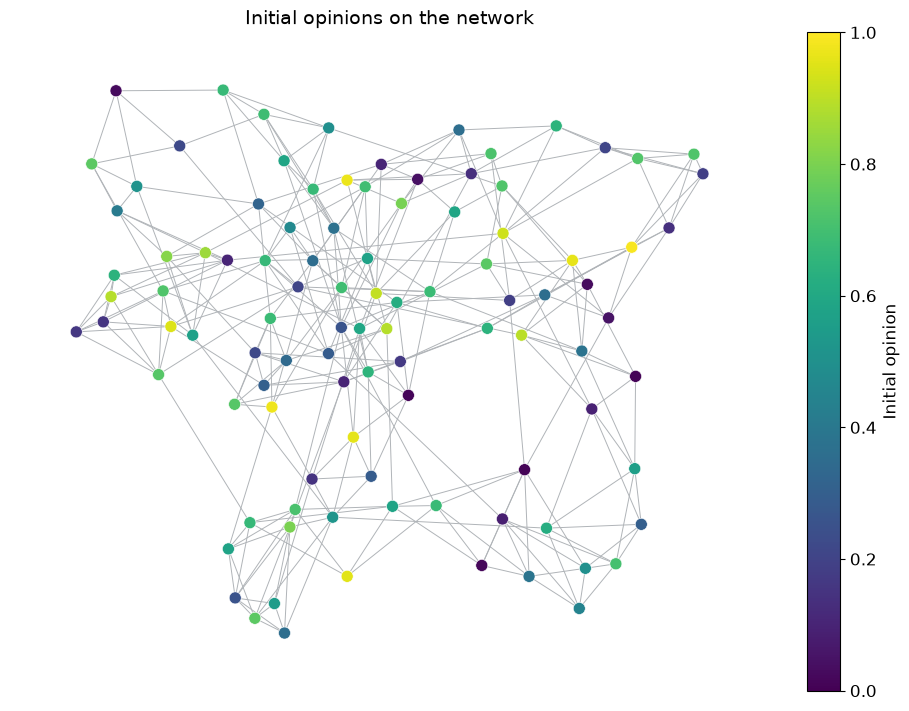

In [66]:
opinion_norm = mcolors.Normalize(vmin=0.0, vmax=1.0)
opinion_cmap = plt.colormaps["viridis"]
opinion_color_scale = plt.cm.ScalarMappable(
    norm=opinion_norm,
    cmap=opinion_cmap,
)


def draw_opinion_network(ax, opinions, title, vertex_size):
    """Draw opinions on the igraph network using vertex-ID order."""
    vertex_colors = [
        mcolors.to_hex(opinion_cmap(opinion_norm(value)))
        for value in opinions
    ]
    assert len(vertex_colors) == graph_ig.vcount()

    ig.plot(
        graph_ig,
        target=ax,
        layout=layout,
        vertex_color=vertex_colors,
        vertex_size=vertex_size,
        vertex_frame_color="white",
        vertex_frame_width=0.4,
        vertex_label=None,
        edge_color="#b0b4b8",
        edge_width=0.7,
        autocurve=False,
    )
    ax.set_title(title)
    ax.axis("off")


fig, ax = plt.subplots(figsize=(9, 7), layout="constrained")
draw_opinion_network(
    ax,
    initial_opinions,
    "Initial opinions on the network",
    vertex_size=12,
)
fig.colorbar(opinion_color_scale, ax=ax, label="Initial opinion")
plt.show()

## 2. Translate the theory into code

The adjacency matrix tells us which agents are connected. We add the identity matrix because each agent also considers its own opinion.

Dividing each row by its sum gives equal influence to the agent and all of its neighbors. The resulting matrix $W$ is row-stochastic.

For this undirected equal-neighbor construction, the theoretical consensus value is

$$
x^* =
\frac{\sum_i (d_i+1)x_i(0)}
     {\sum_i (d_i+1)},
$$

where $d_i$ is the degree of agent $i$. Agents with more neighbors have greater weight in the limiting opinion.

In [67]:
adjacency = np.asarray(graph_ig.get_adjacency().data, dtype=float)
assert adjacency.shape == (N_AGENTS, N_AGENTS)
assert np.array_equal(adjacency, adjacency.T)
assert np.all(np.diag(adjacency) == 0)

# A + I includes both neighbors and the agent itself.
influence_connections = adjacency + np.eye(N_AGENTS)
row_totals = influence_connections.sum(axis=1, keepdims=True)
assert np.allclose(row_totals.ravel(), np.asarray(graph_ig.degree()) + 1)

# Normalize each row so that its influence weights sum to one.
influence_weights = influence_connections / row_totals

assert np.all(influence_weights >= 0)
assert np.allclose(influence_weights.sum(axis=1), 1.0)

theoretical_consensus = np.average(
    initial_opinions,
    weights=row_totals.ravel(),
)

print("First five row sums:", influence_weights.sum(axis=1)[:5])
print(f"Theoretical consensus value: {theoretical_consensus:.3f}")

First five row sums: [1. 1. 1. 1. 1.]
Theoretical consensus value: 0.506


## 3. Run synchronous DeGroot updates

The function stores the initial opinions and every later round. Each new state is computed from the complete previous state, matching the synchronous update equation.

In [68]:
def simulate_degroot(weights, initial_state, n_rounds):
    """Return opinions from round 0 through round n_rounds."""
    history = np.empty((n_rounds + 1, len(initial_state)))
    history[0] = initial_state

    for round_index in range(n_rounds):
        previous_opinions = history[round_index].copy()
        history[round_index + 1] = weights @ previous_opinions

    return history


# A hand-check: two equally weighted agents move to 0.5 in one round.
test_weights = np.array([
    [0.5, 0.5],
    [0.5, 0.5],
])
test_history = simulate_degroot(
    test_weights,
    np.array([0.0, 1.0]),
    n_rounds=1,
)
assert np.allclose(test_history[1], [0.5, 0.5])

opinion_history = simulate_degroot(
    influence_weights,
    initial_opinions,
    N_ROUNDS,
)

# Convex averaging keeps opinions inside their initial range.
assert opinion_history.min() >= initial_opinions.min() - 1e-12
assert opinion_history.max() <= initial_opinions.max() + 1e-12

# The maximum-minus-minimum disagreement cannot increase.
assert np.all(np.diff(np.ptp(opinion_history, axis=1)) <= 1e-12)

final_opinions = opinion_history[-1]

## 4. Compare the initial and final states

Both panels use the same network layout and color scale. This makes changes in opinions visible without confusing them with changes in node position.

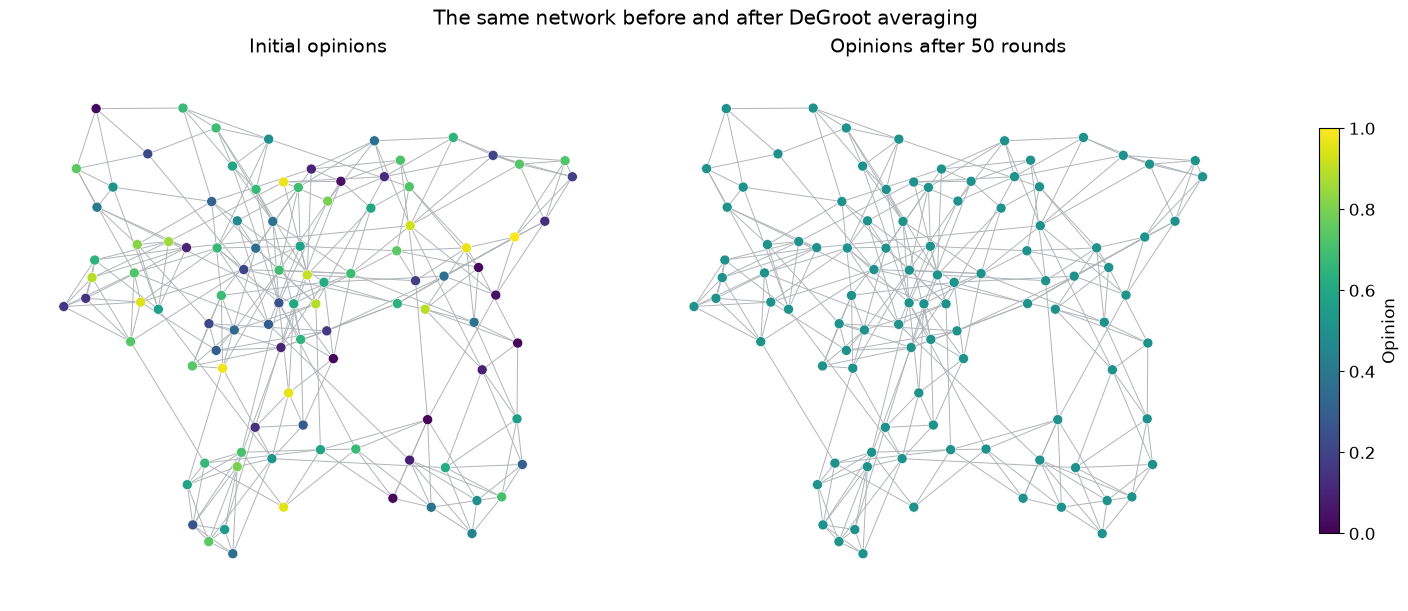

In [ ]:
fig, axes = plt.subplots(
    1,
    2,
    figsize=(14, 6),
    layout="constrained",
)

states = [
    (initial_opinions, "Initial opinions"),
    (final_opinions, f"Opinions after {N_ROUNDS} rounds"),
]

for ax, (opinions, title) in zip(axes, states):
    draw_opinion_network(
        ax,
        opinions,
        title,
        vertex_size=10,
    )

fig.colorbar(
    opinion_color_scale,
    ax=axes,
    label="Opinion",
    shrink=0.75,
)
fig.suptitle(
    "The same network before and after DeGroot"
)
plt.show()

## 5. A typical analysis: does disagreement decrease?

A common analysis follows opinion trajectories and summarizes their dispersion over time.

Here, disagreement is defined as

$$
\max_i x_i(t)-\min_i x_i(t).
$$

Consensus is operationally detected when this range becomes smaller than the chosen tolerance. The theoretical consensus value provides an additional check on the simulation.

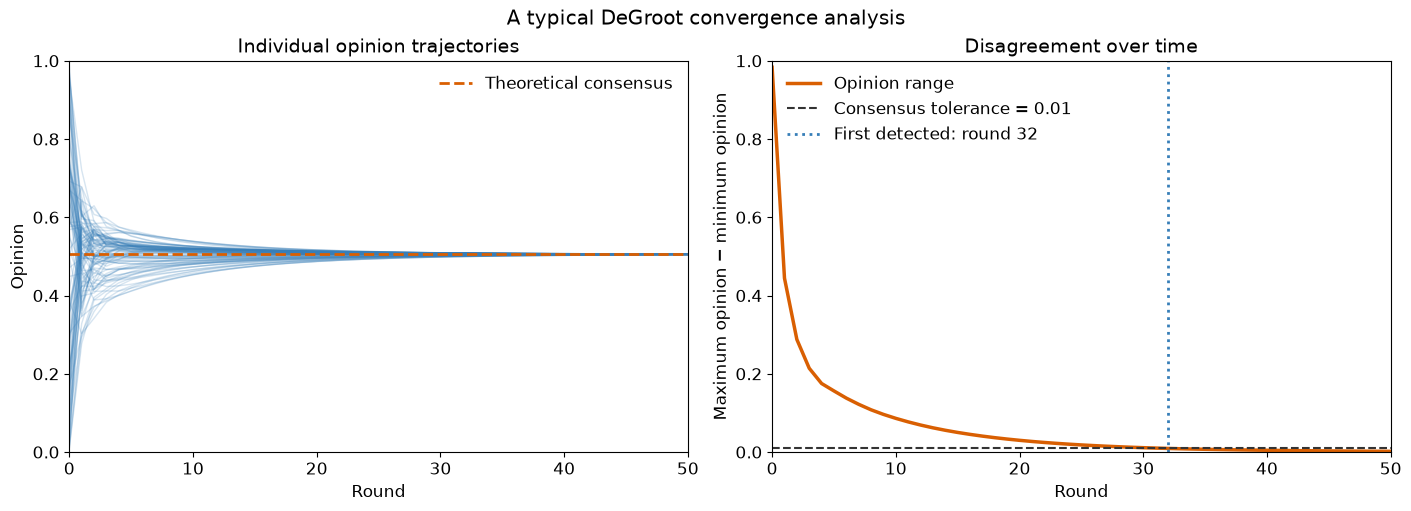

First round below the consensus tolerance: 32
Theoretical consensus: 0.505544
Mean final opinion: 0.505540
Largest final deviation from the theoretical value: 0.001203


In [ ]:
rounds = np.arange(N_ROUNDS + 1)
opinion_range = np.ptp(opinion_history, axis=1)

consensus_rounds = np.flatnonzero(
    opinion_range < CONSENSUS_TOLERANCE
)
first_consensus_round = (
    int(consensus_rounds[0]) if consensus_rounds.size else None
)

fig, axes = plt.subplots(
    1,
    2,
    figsize=(14, 5),
    layout="constrained",
)

axes[0].plot(
    rounds,
    opinion_history,
    color="#377eb8",
    alpha=0.20,
    linewidth=1,
)
axes[0].axhline(
    theoretical_consensus,
    color="#d95f02",
    linestyle="--",
    linewidth=2,
    label="Theoretical consensus",
)
axes[0].set(
    title="Individual opinion trajectories",
    xlabel="Round",
    ylabel="Opinion",
    ylim=(0, 1),
    xlim=(0, N_ROUNDS)
)
axes[0].legend(frameon=False)

axes[1].plot(
    rounds,
    opinion_range,
    color="#d95f02",
    linewidth=2.5,
    label="Opinion range",
)
axes[1].axhline(
    CONSENSUS_TOLERANCE,
    color="#333333",
    linestyle="--",
    label=f"Consensus tolerance = {CONSENSUS_TOLERANCE}",
)

if first_consensus_round is not None:
    axes[1].axvline(
        first_consensus_round,
        color="#377eb8",
        linestyle=":",
        linewidth=2,
        label=f"First detected: round {first_consensus_round}",
    )

axes[1].set(
    title="Disagreement over time",
    xlabel="Round",
    ylabel="Maximum opinion - minimum opinion",
    xlim=(0, N_ROUNDS),
    ylim=(0, 1)
)
axes[1].legend(frameon=False, loc="upper left")

fig.suptitle("A typical DeGroot convergence analysis")
plt.show()

if first_consensus_round is None:
    print("The trajectory did not reach the chosen tolerance.")
else:
    print(
        "First round below the consensus tolerance:",
        first_consensus_round,
    )

print(f"Theoretical consensus: {theoretical_consensus:.6f}")
print(f"Mean final opinion: {final_opinions.mean():.6f}")
print(
    "Largest final deviation from the theoretical value:",
    f"{np.max(np.abs(final_opinions - theoretical_consensus)):.6f}",
)

## Interpretation and limitations

For this connected network with positive self-weights, DeGroot theory guarantees asymptotic consensus. The numerical trajectory illustrates that prediction for one seeded initial condition: disagreement decreases and the opinions approach the degree-weighted theoretical value.

This mathematical conclusion follows from the model assumptions. It is not evidence that a real population must reach consensus.

The model deliberately omits many real mechanisms, including changing relationships, strategic communication, unequal trust beyond network degree, external information, multidimensional beliefs, emotion, institutions, and individual resistance to influence.

Therefore:

- the network is a theoretical representation of possible influence;
- the update equation is a proposed mechanism;
- the simulated trajectory illustrates a consequence of those assumptions;
- the result is not a prediction or complete description of reality.

### Suggested experiments

1. Change `REWIRING_PROBABILITY` within $[0,1]$ and compare convergence speed.
2. Change `NEIGHBORS_ON_EACH_SIDE` to make the network sparser or denser.
3. Replace equal influence with heterogeneous weights while keeping every row sum equal to one.

### Original reference

DeGroot, M. H. (1974). *Reaching a Consensus*. Journal of the American Statistical Association, 69(345), 118–121. [doi:10.1080/01621459.1974.10480137](https://doi.org/10.1080/01621459.1974.10480137).